<img src="../PrimerParcial/img/itq.jpg" style="width:90px;"> <br>
<h2 style="font-family: 'Times New Roman', Times, serif; text-align: center;">PAO25_26_10_Python_Red_Neuronal</h2>
<h2 style="font-family: 'Times New Roman', Times, serif; text-align: center;">Abril 10, 2026</h2>
<p style="font-family: 'Times New Roman', Times, serif; font-weight:bold; font-size:16px;">
</p>

<img src="../PrimerParcial/img/img2.png" alt="imagen" style="display:block; margin: 0 auto;"> </br>

*Bryan Justin Antamba*


## **NUESTRA PRIMERA RED NEURONAL: MNIST DATASET**

In [6]:
!pip install packageName

ERROR: Could not find a version that satisfies the requirement packageName (from versions: none)
ERROR: No matching distribution found for packageName


In [14]:
!pip freeze

absl-py==2.4.0
anyio @ file:///C:/Users/task_177313442920801/croot/anyio_1773134524138/work
argon2-cffi @ file:///C:/Users/task_176606713276293/croot/argon2-cffi_1766067885361/work
argon2-cffi-bindings @ file:///C:/miniconda3/conda-bld/argon2-cffi-bindings_1757925007150/work
asttokens @ file:///C:/Users/task_177313470048861/croot/asttokens_1773135664256/work
astunparse==1.6.3
async-lru @ file:///C:/miniconda3/conda-bld/async-lru_1761121591843/work
attrs @ file:///C:/miniconda3/conda-bld/attrs_1762356954445/work
babel @ file:///C:/miniconda3/conda-bld/babel_1764159347172/work
beautifulsoup4 @ file:///C:/Users/task_177029184171008/croot/beautifulsoup4-split_1770291942989/work
bleach @ file:///C:/miniconda3/conda-bld/bleach_1764153681122/work
brotlicffi @ file:///C:/miniconda3/conda-bld/brotlicffi_1764961370587/work
certifi @ file:///C:/Users/task_176765900829408/croot/certifi_1767659214946/work/certifi
cffi @ file:///C:/miniconda3/conda-bld/cffi_1761832792265/work
charset-normalizer @ fi

Hola voy a ejecutar el comando ```!pip freeze``` para cotillear a Google Colab

In [15]:
!nvidia-smi

Fri Apr 10 14:30:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.97                 Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   43C    P8              5W /   35W |    1313MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
#Importemos TensorFlow 2.X y Numpy
import numpy as np
import tensorflow as tf
tf.__version__

'2.21.0'

#### **- Cargando el conjunto de datos**

In [17]:
# Importamos el dataset MNIST y cargamos los datos
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


#### **- Inspeccionando el conjunto de datos**

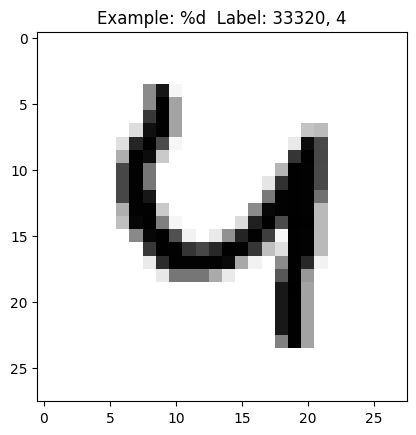

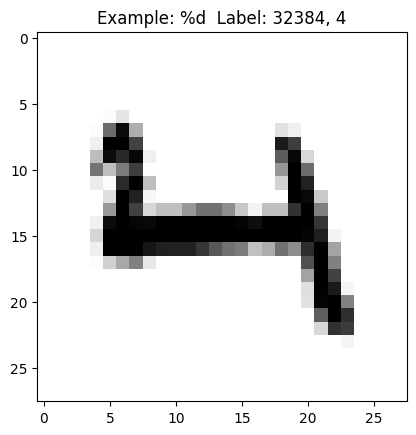

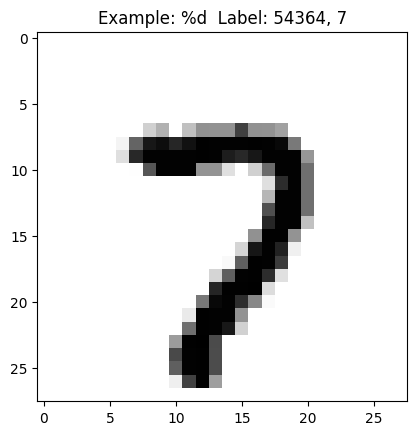

In [18]:
import matplotlib.pyplot as plt
# Función auxiliar para visualizar datos de entrenamiento de manera aleatoria
def display_digit(num,x_train,y_train):
  # Seleccionar la imagen num de mnist.train.images y hacer un reshape al tamaño de la imagen
  image = x_train[num,:,:]
  # Seleccionar el target num de mnist.train.labels
  label = y_train[num]
  # Mostrar
  plt.title(f'Example: %d  Label: {num}, {label}')
  plt.imshow(image, cmap=plt.get_cmap('gray_r'))
  plt.show()

# Mostramos algunos ejemplos
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)

In [19]:
np.random.randint(0, x_train.shape[0])

56617

#### **- Acondicionando el conjunto de datos**

In [20]:
# Pre-procesado obligatorio cuando trabajo con redes neuronales
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_train, x_te = x_train / 255.0, x_test / 255.0 #Cambio al rango 0-1 -> Disminuyo CC
y_train = to_categorical(y_train, num_classes=10) #One-hot encoding para minimizar error
print(y_train.shape)
y_te = to_categorical(y_test, num_classes=10)
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42) # 3 subconjuntos es de vital importancia
print(y_tr.shape)
# print(y_tr[0])

(60000, 10)
(54000, 10)


In [21]:
print(y_tr[25050])

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [22]:
print(y_tr[25050].argmax(axis=0))

6


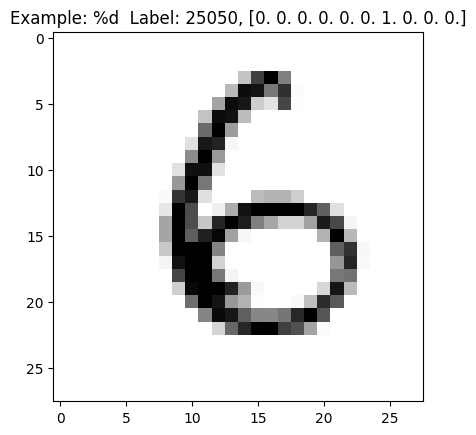

In [23]:
display_digit(25050, x_tr,y_tr)

#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [24]:
# Voy a necesitar importar una serie de modulos para programar mi red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
# Vamos a codificar la topología de nuestra primera red neuronal!!!
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(512, input_shape=(28*28,), activation="relu"))
model.add(Dense(10, activation="softmax")) #Capa salida -> Mismo número de neuronas que de clases objetivo

# Ahí tenemos nuestro primer MLP con una única capa oculta de 512 neuronas

C:\Users\Asus\anaconda3\envs\Maquina1\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Asus\anaconda3\envs\Maquina1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
#Traigamos nuestro optimizador
from tensorflow.keras.optimizers import SGD
# Ahora que tengo definida la arquitectura, la compilo
model.compile(loss="categorical_crossentropy", optimizer=SGD(0.005), metrics=["accuracy"])

In [26]:
######### Modelo funcional ############ (Clase 04/10/2023)
# Definir la entrada
input_layer = Input(shape=(28, 28))
# Capa de aplanamiento
x = Flatten()(input_layer)
x = Dense(512, activation="relu")(x)
# x= Dropout(0.5)(x) Introducción de capa de dropout en un modelo funcional
output_layer = Dense(10, activation="softmax")(x)
# Crear el modelo
model = Model(inputs=input_layer, outputs=output_layer)

In [27]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

None


In [28]:
# Por fin podemos entrenar nuestra primera red neuronal
print("[INFO]: Entrenando red neuronal...")
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
H = model.fit(x_tr, y_tr, validation_data=(x_val, y_val), epochs=50, batch_size=128)

[INFO]: Entrenando red neuronal...
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9198 - loss: 0.2800 - val_accuracy: 0.9580 - val_loss: 0.1473
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9662 - loss: 0.1153 - val_accuracy: 0.9715 - val_loss: 0.0966
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9772 - loss: 0.0763 - val_accuracy: 0.9758 - val_loss: 0.0805
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9840 - loss: 0.0545 - val_accuracy: 0.9775 - val_loss: 0.0769
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9884 - loss: 0.0399 - val_accuracy: 0.9828 - val_loss: 0.0617
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9918 - loss: 0.0287 - val_accuracy: 0.9793 - val_loss: 0.0653
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9945 - loss: 0.0216 - val_accuracy: 0.9833 - val_loss: 0.0584
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.995

#### **- Observando el proceso de entrenamiento para tomar decisiones**

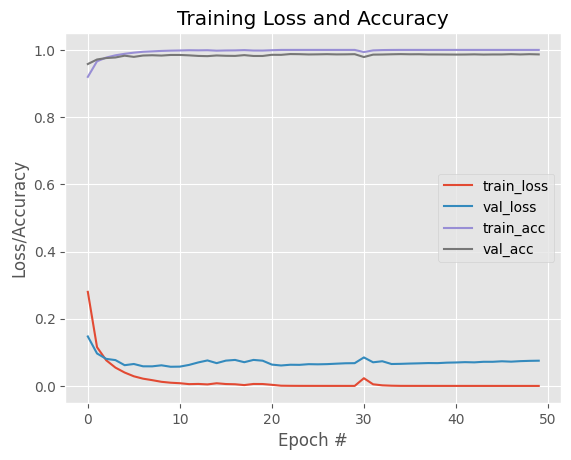

In [29]:
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 50), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 50), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [30]:
from sklearn.metrics import classification_report
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
predictions = model.predict(x_te, batch_size=128)
print(y_te[0])
print(predictions[0])
print(classification_report(y_te.argmax(axis=1), predictions.argmax(axis=1)))

[INFO]: Evaluando red neuronal...
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[1.1174415e-16 3.6424394e-20 4.5320108e-15 1.1505043e-10 8.4925327e-22
 6.0208785e-18 3.4156447e-24 1.0000000e+00 1.5211457e-16 6.5797964e-13]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.99       892
           6       0.99      0.98      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     

In [31]:
predictions[0].argmax(axis=0)

np.int64(7)

In [32]:
y_te[0].argmax(axis=0)

np.int64(7)

In [33]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,221,152 (4.66 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 814,102 (3.11 MB)

None


--------------------------------------------------------------------------

## **MLP APLICADO A TEXTO: EJEMPLO REUTERS**

#### **- Cargando el conjunto de datos**

In [34]:
import numpy as np
import tensorflow as tf
# Importamos el dataset REUTERS y cargamos los datos
reuters = tf.keras.datasets.reuters
WORD_LIMIT = 10000
(training_data, training_labels), (testing_data, testing_labels) = reuters.load_data(num_words=WORD_LIMIT)
print(training_data.shape)
print(training_labels.shape)
print(testing_data.shape)
print(testing_labels.shape)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


C:\Users\Asus\anaconda3\envs\Maquina1\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


(8982,)
(8982,)
(2246,)
(2246,)


#### **- Inspeccionando el conjunto de datos**

In [35]:
# Los datos son numericos para decodificarlos, se puede usar reuters.get_word_index()
word_index = reuters.get_word_index()
reverse_word_index = dict({value : key for key, value in word_index.items()})
decoded = ' '.join(
    [reverse_word_index.get(i-3,'?') for i in training_data[5]]
)
decoded

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


"? the u s agriculture department estimated canada's 1986 87 wheat crop at 31 85 mln tonnes vs 31 85 mln tonnes last month it estimated 1985 86 output at 24 25 mln tonnes vs 24 25 mln last month canadian 1986 87 coarse grain production is projected at 27 62 mln tonnes vs 27 62 mln tonnes last month production in 1985 86 is estimated at 24 95 mln tonnes vs 24 95 mln last month canadian wheat exports in 1986 87 are forecast at 19 00 mln tonnes vs 18 00 mln tonnes last month exports in 1985 86 are estimated at 17 71 mln tonnes vs 17 72 mln last month reuter 3"

#### **- Acondicionando el conjunto de datos**

In [36]:
# Función auxiliar para representar las palabras (que no entiende nuestra red neuronal) en números
import numpy as np
# one hot encoding del input, vector con cada indice indicando si una palabra esta presente
def one_hot_encode(data):
    encoded = np.zeros((len(data),WORD_LIMIT))
    for i, v in enumerate(data):
        encoded[i,v] = 1 # localiza las columnas del genero correspondiente, marca con 1
    return encoded

In [37]:
# Convertimos nuestras palabras a números
x_train = one_hot_encode(training_data)
x_test = one_hot_encode(testing_data)
print(x_train.shape)
print(x_test.shape)

(8982, 10000)
(2246, 10000)


In [38]:
print(x_test[3])

[0. 1. 1. ... 0. 0. 0.]


In [39]:
# Convertimos nuestros labels (categoría reseña) a one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(training_labels)
y_test = to_categorical(testing_labels)
print(y_train.shape)
print(y_test.shape)

(8982, 46)
(2246, 46)


In [40]:
print(y_test[3])

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Vamos a codificar la topología de nuestro MLP
model = Sequential()
model.add(Dense(128,activation='relu',input_shape=(WORD_LIMIT,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes
# En el caso de regresión cambiamos la ultima capa por:
#model.add(Dense(1,activation='sigmoid'))

C:\Users\Asus\anaconda3\envs\Maquina1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
# Ahora que tengo definida la arquitectura, la compilo
model.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase/ para regresion (mse/mae)
               metrics=['accuracy'])

In [43]:
# A entrenar nuestra red neuronal sea dicho!
H = model.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6820 - loss: 1.4935 - val_accuracy: 0.7791 - val_loss: 0.9974
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8800 - loss: 0.5466 - val_accuracy: 0.7997 - val_loss: 0.8699
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9411 - loss: 0.2744 - val_accuracy: 0.8047 - val_loss: 0.9000
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9543 - loss: 0.1892 - val_accuracy: 0.8052 - val_loss: 0.9152
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9598 - loss: 0.1604 - val_accuracy: 0.8119 - val_loss: 0.9246
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9592 - loss: 0.1426 - val_accuracy: 0.8024 - val_loss: 0.9938
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9608 - loss: 0.1265 - val_accuracy: 0.7930 - val_loss: 1.0296
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9601 - loss: 0.1154 - val_accuracy: 0.

#### **- Observando el proceso de entrenamiento para tomar decisiones**

In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │       1,280,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 46)                  │           2,990 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,874,124 (14.78 MB)

 Trainable params: 1,291,374 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,582,750 (9.85 MB)

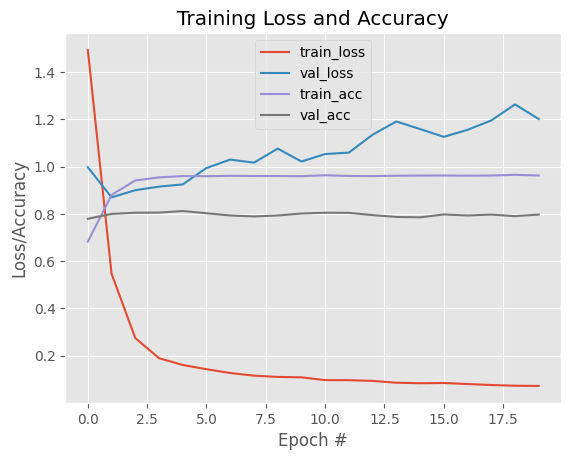

In [45]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [46]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model.predict(x_test)
loss, accuracy = model.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7872 - loss: 1.3222
Loss 1.3221617937088013, accuracy 0.7871772050857544


## **REGULARIZACIÓN EN APRENDIZAJE PROFUNDO**

#### **- Weight regularization L1/L2**

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
# Vamos a codificar la topología de nuestro MLP
model_reg = Sequential()
model_reg.add(Dense(128,activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(WORD_LIMIT,)))
model_reg.add(Dense(64,activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model_reg.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\Asus\anaconda3\envs\Maquina1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
# Ahora que tengo definida la arquitectura, la compilo
model_reg.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [49]:
# A entrenar nuestra red neuronal sea dicho!
H = model_reg.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6537 - loss: 2.4025 - val_accuracy: 0.7067 - val_loss: 1.8444
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7397 - loss: 1.7025 - val_accuracy: 0.7412 - val_loss: 1.6985
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7553 - loss: 1.6022 - val_accuracy: 0.7362 - val_loss: 1.6741
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7619 - loss: 1.5468 - val_accuracy: 0.7501 - val_loss: 1.5973
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7706 - loss: 1.4991 - val_accuracy: 0.7507 - val_loss: 1.6051
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7794 - loss: 1.4607 - val_accuracy: 0.7579 - val_loss: 1.5687
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7832 - loss: 1.4536 - val_accuracy: 0.7607 - val_loss: 1.5545
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7939 - loss: 1.4086 - val_accuracy: 0

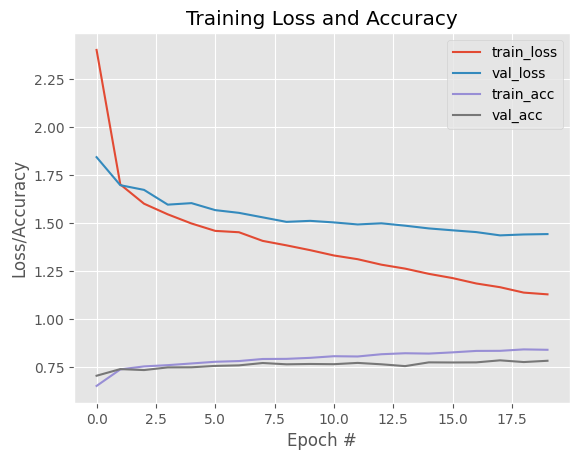

In [50]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [51]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_reg.predict(x_test)
loss, accuracy = model_reg.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7663 - loss: 1.4849
Loss 1.4849282503128052, accuracy 0.7662510871887207


#### **- Dropout**

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
# Vamos a codificar la topología de nuestro MLP
model_drop = Sequential()
model_drop.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(64,activation='relu'))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\Asus\anaconda3\envs\Maquina1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
# Ahora que tengo definida la arquitectura, la compilo
model_drop.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [54]:
# A entrenar nuestra red neuronal sea dicho!
H = model_drop.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5379 - loss: 2.0358 - val_accuracy: 0.7095 - val_loss: 1.3244
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6792 - loss: 1.3410 - val_accuracy: 0.7446 - val_loss: 1.1626
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7282 - loss: 1.1057 - val_accuracy: 0.7657 - val_loss: 1.0688
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7644 - loss: 0.9555 - val_accuracy: 0.7741 - val_loss: 1.0436
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7942 - loss: 0.8358 - val_accuracy: 0.7858 - val_loss: 1.0175
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8067 - loss: 0.7650 - val_accuracy: 0.7885 - val_loss: 1.0118
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8216 - loss: 0.6913 - val_accuracy: 0.7902 - val_loss: 1.0226
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8326 - loss: 0.6523 - val_accuracy: 0.

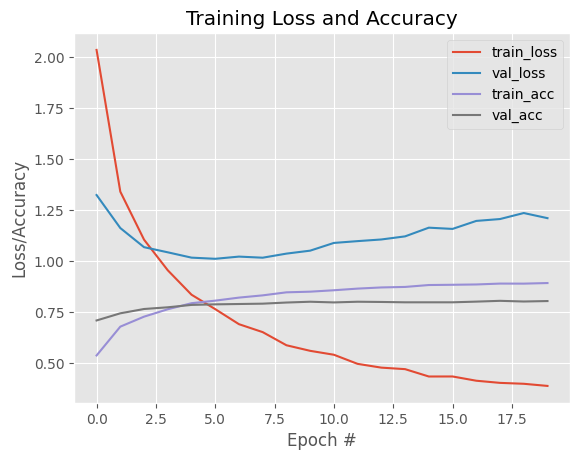

In [56]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

# ¿Y si desconectamos mayor porcentaje de neuronas?

In [57]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_drop.predict(x_test)
loss, accuracy = model_drop.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7974 - loss: 1.3362
Loss 1.336158037185669, accuracy 0.7974176406860352


#### **- Batch Normalization**

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
# Vamos a codificar la topología de nuestro MLP
model_bn = Sequential()
model_bn.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(64,activation='relu'))
model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\Asus\anaconda3\envs\Maquina1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
# Ahora que tengo definida la arquitectura, la compilo
model_bn.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [60]:
# A entrenar nuestra red neuronal sea dicho!
H = model_bn.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4813 - loss: 2.4735 - val_accuracy: 0.6856 - val_loss: 1.5163
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6688 - loss: 1.5438 - val_accuracy: 0.7418 - val_loss: 1.1827
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7122 - loss: 1.2799 - val_accuracy: 0.7618 - val_loss: 1.0865
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7531 - loss: 1.0867 - val_accuracy: 0.7769 - val_loss: 1.0362
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7694 - loss: 0.9685 - val_accuracy: 0.7902 - val_loss: 1.0026
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7923 - loss: 0.8669 - val_accuracy: 0.7963 - val_loss: 0.9732
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8007 - loss: 0.8129 - val_accuracy: 0.8008 - val_loss: 0.9586
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8238 - loss: 0.7194 - val_accuracy: 0

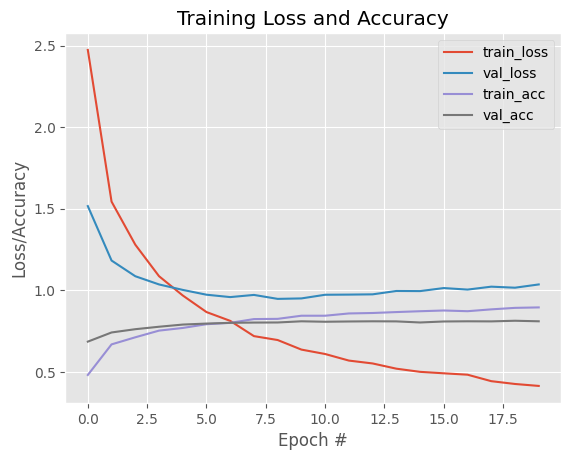

In [61]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [77]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_bn.predict(x_test)
loss, accuracy = model_bn.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8045 - loss: 1.0916
Loss 1.0916162729263306, accuracy 0.8045414090156555


### **Ejercicio Practico**

Realizar en una hoja en blanco un numero deseado para luego predecir que tipo de numero es el que se escojio.

In [2]:
import cv2
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPooling2D, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# 1. Cargado y preparacion de los datos
(x_train, y_train), _ = mnist.load_data()

x_train = x_train / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)

# 2. Modelo
model = Sequential([
    Input(shape=(28,28,1)),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(10, activation='softmax')
])

# 3. Compilacion
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. EEntrenamiento
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,  # Le damos mas aprendisaje en nuestro entrenamiento
    restore_best_weights=True
)

model.fit(x_train, y_train,
          epochs=30, 
          validation_split=0.1,
          callbacks=[early_stop],
          verbose=1)

# Cargamos la imagen del numero escojido
img = cv2.imread('img/numeroDos.jpeg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: no se pudo cargar la imagen")
else:
    # Rendimesionamos grande primero la imagen
    img = cv2.resize(img, (100, 100))

    # Inversion de los colores
    img = 255 - img

    # Binarizar, limpiamos ruidos
    _, img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)

    # Centramos el numero de iamgen para tener una mejor precisión
    coords = np.column_stack(np.where(img > 50))
    if coords.size > 0:
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]

    # Redimensionar a formato MNIST
    img = cv2.resize(img, (28, 28))

    # Normalizacion
    img = img / 255.0
    img = img.astype("float32")

    img = np.reshape(img, (1, 28, 28, 1))

    print("Shape:", img.shape)

    # 6. Prediccion
    pred = model.predict(img)

    print("Probabilidades:", pred)
    print("Número predicho:", np.argmax(pred))

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9571 - loss: 0.1397 - val_accuracy: 0.9847 - val_loss: 0.0499
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9803 - loss: 0.0641 - val_accuracy: 0.9885 - val_loss: 0.0375
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9851 - loss: 0.0490 - val_accuracy: 0.9898 - val_loss: 0.0390
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9882 - loss: 0.0398 - val_accuracy: 0.9907 - val_loss: 0.0345
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9894 - loss: 0.0330 - val_accuracy: 0.9920 - val_loss: 0.0315
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9909 - loss: 0.0282 - val_accuracy: 0.9912 - val_loss: 0.0351
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9921 - loss: 0.0239 - val_accuracy: 0.9910 - val_loss: 0.0313
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9934 - loss: 0

https://github.com/BryanAntamba/machine2026-PrimerParcial/blob/main/Machine%20E-learning%202/SegundoParcial/Introducción%20a%20Deep%20Learning_Colab_clase.ipynb